In [18]:
import pandas as pd

news_df = pd.read_csv(r"C:\sentiment_analysis\raw_analyst_ratings.csv")
stock_df = pd.read_csv(r"C:\sentiment_analysis\Data\AAPL.csv")
stock_df = pd.read_csv(r"C:\sentiment_analysis\Data\AMZN.csv")
stock_df = pd.read_csv(r"C:\sentiment_analysis\Data\GOOG.csv")
stock_df = pd.read_csv(r"C:\sentiment_analysis\Data\META.csv")
stock_df = pd.read_csv(r"C:\sentiment_analysis\Data\NVDA.csv")
print(news_df.columns)
news_df["date"] = pd.to_datetime(news_df["date"], errors="coerce")
news_df = news_df.dropna(subset=['date'])
news_df['date'] = pd.to_datetime(news_df['date'], utc=True).dt.tz_convert(None)
print(stock_df.columns)
stock_df["Date"] = pd.to_datetime(stock_df["Date"]).dt.tz_localize(None)

stock_df = stock_df.sort_values('Date')

stock_df['daily_return'] = (
    (stock_df['Close'] - stock_df['Close'].shift(1))
    / stock_df['Close'].shift(1)
) * 100

Index(['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock'], dtype='str')
Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')


In [19]:
news_df['trading_day'] = news_df['date'].apply(
    lambda x: align_to_trading_day(x, trading_days)
)


stock_df = stock_df.sort_values('Date')
trading_days = stock_df['Date'].unique()
trading_days = pd.to_datetime(trading_days).tz_localize(None)

def align_to_trading_day(ts, trading_days):
    if pd.isna(ts):
        return None
    ts = ts.normalize()
    idx = trading_days.searchsorted(ts)
    if idx < len(trading_days):
        return trading_days[idx]
    return None

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

news_df['sentiment_score'] = news_df['headline'].apply(
    lambda x: analyzer.polarity_scores(str(x))['compound']
)

print(news_df[['date', 'trading_day']].head())

daily_sentiment = (
    news_df.groupby('trading_day')['sentiment_score']
    .mean()
    .reset_index()
)

                 date trading_day
0 2020-06-05 14:30:54  2020-06-05
1 2020-06-03 14:45:20  2020-06-03
2 2020-05-26 08:30:07  2020-05-26
3 2020-05-22 16:45:06  2020-05-22
4 2020-05-22 15:38:59  2020-05-22


Merge with Daily Stock Returns

In [20]:
merged = pd.merge(
    stock_df[['Date', 'daily_return']],
    daily_sentiment,
    left_on='Date',
    right_on='trading_day',
    how='left'
)

fill missing sentiment values

In [21]:
merged['sentiment_score'] = merged['sentiment_score'].fillna(0)

computing Pearson correlation

In [22]:
from scipy.stats import pearsonr

corr, p = pearsonr(
    merged['sentiment_score'].fillna(0),
    merged['daily_return'].fillna(0)
)

print("Pearson Correlation:", corr)
print("P-value:", p)

Pearson Correlation: 0.01817888629245388
P-value: 0.26420653148556333


Scatter Plot with Correlation Annotation

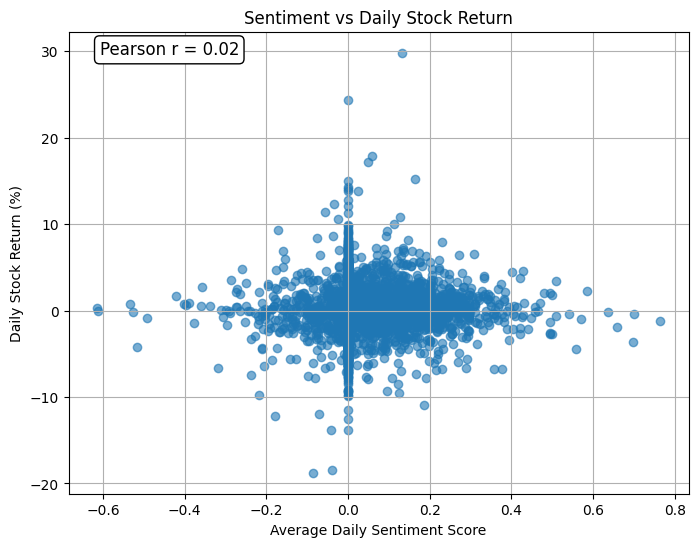

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    merged['sentiment_score'],
    merged['daily_return'],
    alpha=0.6
)

plt.xlabel("Average Daily Sentiment Score")
plt.ylabel("Daily Stock Return (%)")
plt.title("Sentiment vs Daily Stock Return")

plt.annotate(
    f"Pearson r = {corr:.2f}",
    xy=(0.05, 0.95),
    xycoords='axes fraction',
    fontsize=12,
    bbox=dict(boxstyle="round", fc="white")
)

plt.grid(True)
plt.show()

Classify Sentiment Categories

In [32]:
def classify_sentiment(score):

    if score > 0.05:
        return 'Positive'

    elif score < -0.05:
        return 'Negative'

    else:
        return 'Neutral'
merged['sentiment_category'] = merged['sentiment_score'].apply(
    classify_sentiment
)

  

Average Return per Sentiment Category

In [33]:
category_returns = (
    merged.groupby('sentiment_category')['daily_return']
    .mean()
    .reset_index()
)

print(category_returns)

  sentiment_category  daily_return
0           Negative     -0.303982
1            Neutral      0.194797
2           Positive      0.272270


Bar Chart of Average Returns by Sentiment

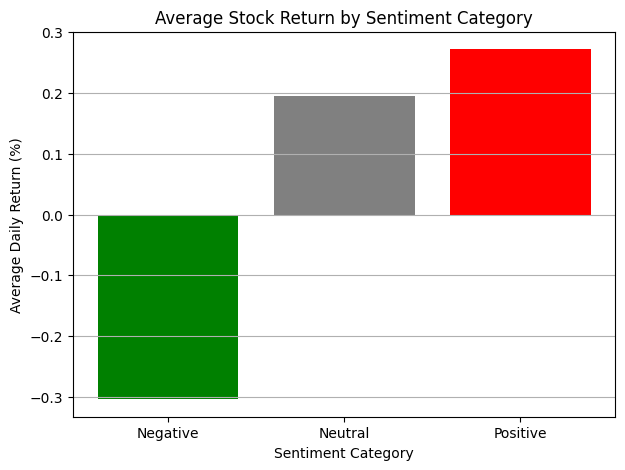

In [34]:
plt.figure(figsize=(7,5))

plt.bar(
    category_returns['sentiment_category'],
    category_returns['daily_return'],
    color=['green', 'gray', 'red']
)

plt.xlabel("Sentiment Category")
plt.ylabel("Average Daily Return (%)")
plt.title("Average Stock Return by Sentiment Category")

plt.grid(axis='y')
plt.show()